<a href="https://colab.research.google.com/github/seik345/EstadisticaInferencial2026/blob/main/Problemario/Problema_1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problema 1
Un profesor intenta mostrar a sus estudiantes la importancia de los exámenes cortos, aun cuando el 90% de la calificación final esté determinada por los exámenes parciales. Él cree que cuanto más altas sean las calificaciones de los exámenes cortos, más alta será la calificación final. Seleccionó una muestra aleatoria de 15 estudiantes de su clase con los siguientes datos:

| Promedio de exámenes cortos | Promedio final |
|--------------|--------------|
| 59 | 64 |
| 92 | 84 |
| 72 | 77 |
| 90 | 80 |
| 95 | 77 |
| 87 | 81 |
| 89 | 80 |
| 77 | 84 |
| 76 | 80 |
| 65 | 69 |
| 97 | 83 |
| 42 | 40 |
| 94 | 78 |
| 62 | 65 |
| 91 | 90 |



1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
12. Realice una tabla ANOVA e interprete el resultado.




In [ ]:
import pandas as pd
#esto es para cargar datos
df = pd.DataFrame({
    "promedio_examenes_cortos": [59,92,72,90,95,87,89,77,76,65,97,42,94,62,91],
    "promedio_final":[64,84,77,80,77,81,80,84,80,69,83,40,78,65,90]
})

df

,promedio_examenes_cortos,promedio_final
0,59,64
1,92,84
2,72,77
3,90,80
4,95,77
5,87,81
6,89,80
7,77,84
8,76,80
9,65,69


In [ ]:
mi_nombre="Said"

In [ ]:
mi_nombre

'Said'

1.  **Establesca una variable dependiente ($Y$) y una variable independiente ($X$).**

+ $Y$: es el promedio final ya que este depende de la calificación o promedio de los examenes cortos durante el curso.
+ $X$: son las ausencias porque no afectan en nada ya que son dependientes a cada persona o situación.


In [ ]:
# Que la informacion tengo (x) Variable independiente
# Que quiero predecir (y) Variable dependiente

Y = df["promedio_final"]
X = df["promedio_examenes_cortos"]

2. **Realice un diagrama de dispersión para estos datos**

/tmp/ipykernel_4019/2179340883.py:11: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


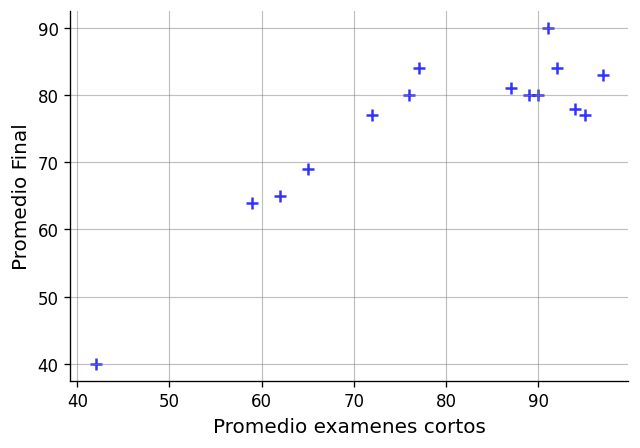

In [ ]:

# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="+",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio examenes cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Promedio Final', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='-',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

3. **¿Los datos soportan la suposición de linealidad?**

 Si porque los datos se muestran en forma paralela respecto a la forma diagonal de la línea.

4. **Calcule el coeficiente de correlación e interprete el resultado**


In [ ]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
valor_p:  0.0000


El coeficiente de correlación es $$r=0.8646$$ este valor indica que la correlación es fuerte, dado que está muy cerca de 1. Además, el que sea positiva, implica que aumentar el promedio de examenes cortos ($X$) aumenta el promedio final ($Y$).

5. **Calcule el coeficiente de determinación e interprete el resultado.**

In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada=modelo.predict(x_constante)

modelo.params

,0
const,24.526822
promedio_examenes_cortos,0.643180


In [ ]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  74.75%


Con coeficiente de determinación de $$r^2=0.7475$$ indica que con las ausencias estoy justificando en un $74.75\%$ la variabilidad en los promedios finales. Por lo que el modelo puede tener una buena capacidad de predicción.



6. **Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión**

In [ ]:
modelo.params

,0
const,24.526822
promedio_examenes_cortos,0.643180


El modelo es:

$$
\hat{y}=24.526822+0.643180x
$$

donde $x$ es el promedio en examenes cortos.

In [ ]:
24.5268+0.643180*(59)

62.47442

In [ ]:
#modelo.predict(´[1, 59])

modelo.predict([1, 59])

array([62.47443345])

/tmp/ipykernel_4019/611141188.py:11: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


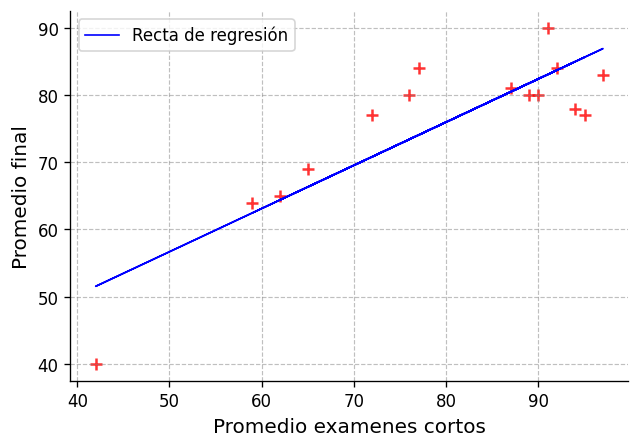

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="+",       # forma: googlear "matplotlib.markers"
    color='red',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='blue',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio examenes cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Promedio final', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Leyenda
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)



7. **Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

La recta tiene la forma:

$$\hat{y}=b_0+b_1X$$


In [ ]:
modelo.conf_int(alpha=0.05)

,0,1
const,6.441997,42.611646
promedio_examenes_cortos,0.419219,0.867141


El verdadero $b_0$ está entre $11.587445$ y $16.530241$ con una confianza del 95%. Esto indica que una persona sin ausencias ($X=0$) tiene una categoría de salario ($Y$) que está entre estos dos valores.

El verdadero valor de $b_1$ está entre $-0.350638$ y $-0.172989$ con un 95% de confianza. Dado que dentro de este intervalo no está el valor de cero, entonces la relación es significativa. También indica que por cada falta se pierde entre 0.172989 y 0.350638 en la categoría de salario.

8. **Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [ ]:
residuales = modelo.resid

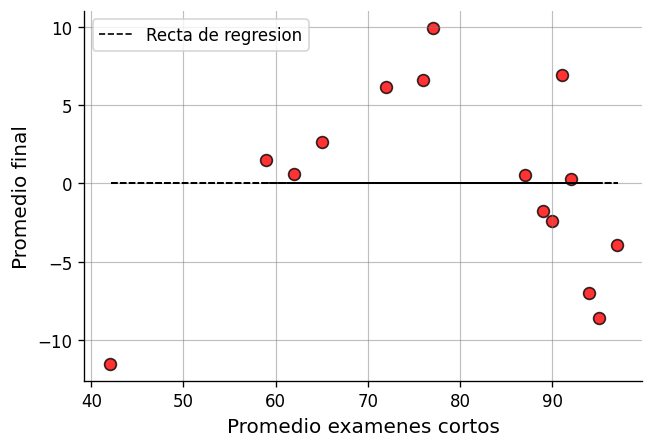

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='red',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0, # <------------------------------------------------------
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label="Recta de regresion"
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio examenes cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Promedio final', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Leyenda
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='-',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

Para los supuestos:


+ Linealidad: No cumple, porque aunque van sobre la recta, pero confuso por la cantidad de datos ya que no es equitativo sobre y bajo la línea.
+ Normalidad: Sí cumple con la normalidad, porque hay puntos cerca de la línea.
+ Homoscedasticidad: Sí cumple con la homoscedasticidad, porque los puntos estan dispersos.
+ Independencia: Sí cumple, porque son diferentes unidades.

9. **Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.901827735700704


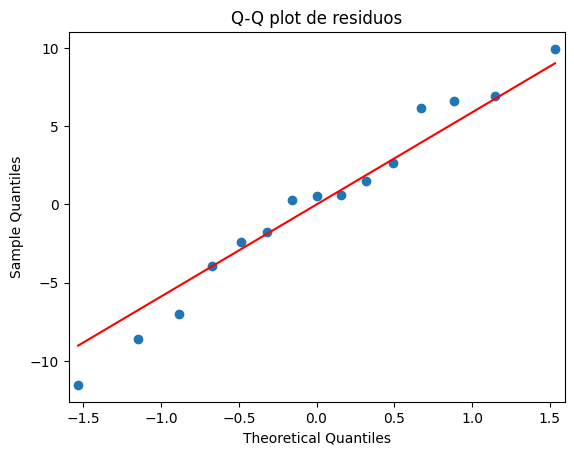

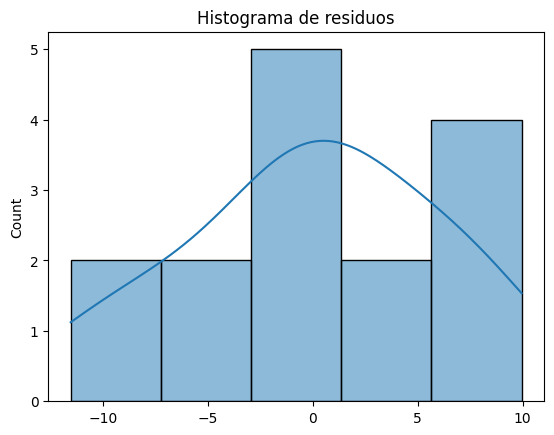

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

10. **Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.2289



11. **Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

Si el modelo cumple con todos los supuestos, es confiable para

---

interpolación.

In [ ]:
# mínimo promedio examenes cortos: 42
# máximo promedio examenes cortos: 97

# interpolar, valores de x entre 42 y 97

# interpolar
y_69 = modelo.predict([1, 69])
y_85 = modelo.predict([1, 85])

print(f"Para x = 69, y =  {y_69[0]: 0.4f}")
print(f"Para x = 85, y =  {y_85[0]: 0.4f}")

Para x = 69, y =   68.9062
Para x = 85, y =   79.1971


In [ ]:
df["promedio_examenes_cortos"] = y_calculada.round()
df

,promedio_examenes_cortos,promedio_final
0,62.0,64
1,84.0,84
2,71.0,77
3,82.0,80
4,86.0,77
5,80.0,81
6,82.0,80
7,74.0,84
8,73.0,80
9,66.0,69


In [ ]:
# mínimo promedio examenes cortos: 42
# máximo promedio examenes cortos: 97

# Extrapolar, valores de x que no estén entre 42 y 97

y_29 = modelo.predict([[1, 29]])

print(f"Para x = 29, y =  {y_29[0]: 0.4f}")

Para x = 29, y =   43.1790


Con 29 promedios de examenes cortos se espera que el alumno tenga una calificación final en promedio de 43. Este valor se obtuvo por medio de extrapolación, por lo que se toma con reservas.

12. **Realice una tabla ANOVA e interprete el resultado.**

In [ ]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols(
    '''promedio_final ~ promedio_examenes_cortos''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
promedio_examenes_cortos,1.0,1511.068213,1511.068213,35.934041,0.000045
Residual,13.0,546.665120,42.051163,NaN,NaN


Sí hay correlación porque el valor-p de $0.000045$ es menor a un nivel de significancia $\alpha=0.05$.

En los residuales del anova se puede ver la diferencia entre el valor real observado y el valor predicho por el modelo (la media de su respectivo grupo).